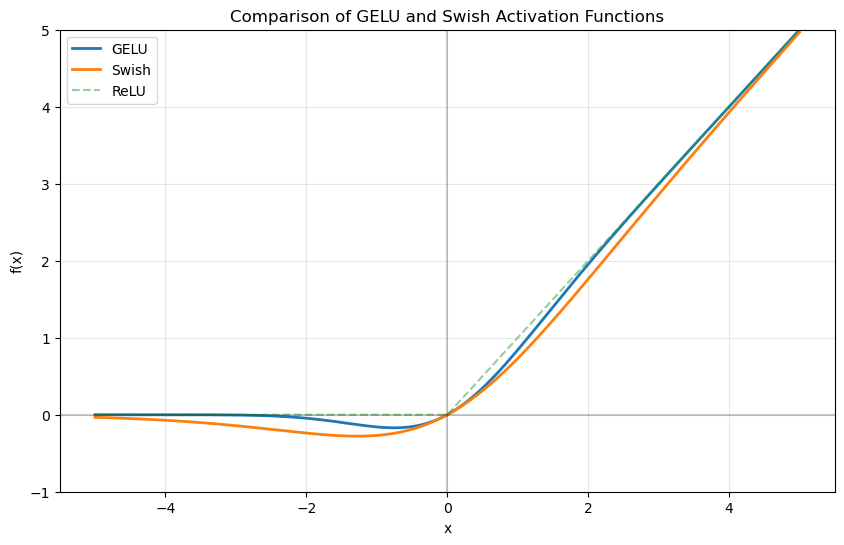

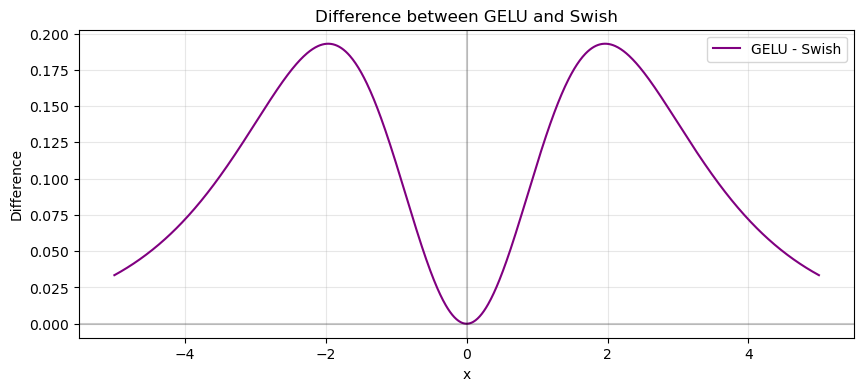

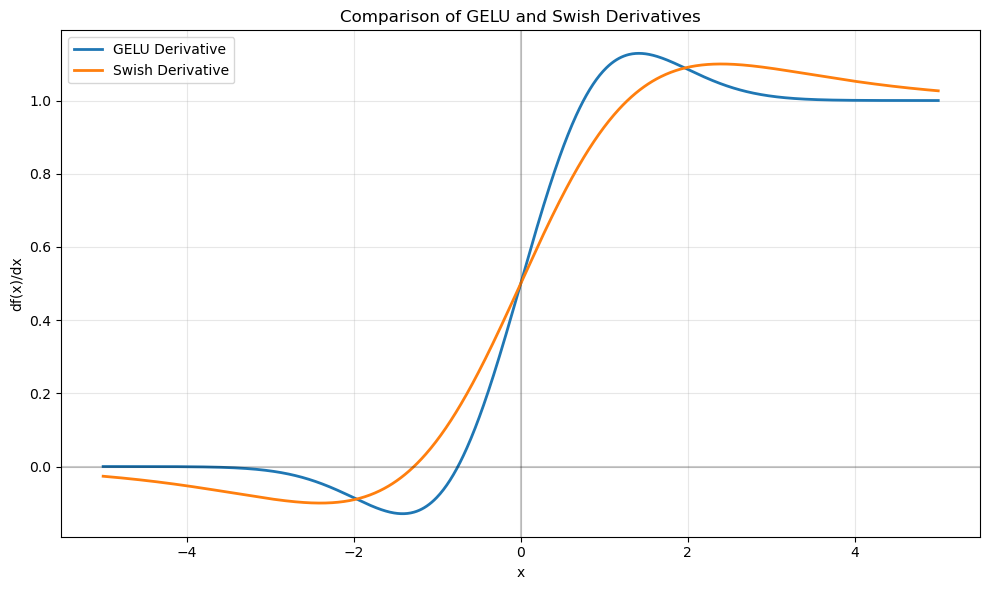

GELUとSwishの主な違い:
1. 負の入力値での挙動: GELUは負の入力をより強く抑制します
2. 飽和特性: 大きな正の値ではSwishはほぼ線形に近づきますが、GELUは若干異なる挙動を示します
3. ゼロ付近の滑らかさ: 両方とも滑らかですが、傾きが少し異なります
4. 計算コスト: Swishはシグモイド関数のみを使うため、やや効率的です


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F

# 入力範囲の定義
x = np.linspace(-5, 5, 1000)
x_tensor = torch.tensor(x, dtype=torch.float32)

# GELU関数の実装
def gelu(x_tensor):
    return F.gelu(x_tensor)

# Swish関数の実装
def swish(x_tensor):
    return x_tensor * torch.sigmoid(x_tensor)

# 活性化関数の計算
gelu_values = gelu(x_tensor).numpy()
swish_values = swish(x_tensor).numpy()

# プロットの作成
plt.figure(figsize=(10, 6))
plt.plot(x, gelu_values, label='GELU', linewidth=2)
plt.plot(x, swish_values, label='Swish', linewidth=2)
plt.plot(x, np.maximum(0, x), '--', label='ReLU', alpha=0.5)
plt.grid(True, alpha=0.3)
plt.axhline(y=0, color='k', linestyle='-', alpha=0.2)
plt.axvline(x=0, color='k', linestyle='-', alpha=0.2)
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Comparison of GELU and Swish Activation Functions')
plt.legend()
plt.ylim(-1, 5)

# 2つの関数の差を計算
plt.figure(figsize=(10, 4))
plt.plot(x, gelu_values - swish_values, label='GELU - Swish', color='purple')
plt.grid(True, alpha=0.3)
plt.axhline(y=0, color='k', linestyle='-', alpha=0.2)
plt.axvline(x=0, color='k', linestyle='-', alpha=0.2)
plt.xlabel('x')
plt.ylabel('Difference')
plt.title('Difference between GELU and Swish')
plt.legend()

# 両関数の導関数を計算
x_tensor.requires_grad_(True)
gelu_output = gelu(x_tensor)
swish_output = swish(x_tensor)

gelu_grad = torch.autograd.grad(gelu_output.sum(), x_tensor)[0].numpy()
swish_grad = torch.autograd.grad(swish_output.sum(), x_tensor)[0].numpy()

# 導関数のプロット
plt.figure(figsize=(10, 6))
plt.plot(x, gelu_grad, label='GELU Derivative', linewidth=2)
plt.plot(x, swish_grad, label='Swish Derivative', linewidth=2)
plt.grid(True, alpha=0.3)
plt.axhline(y=0, color='k', linestyle='-', alpha=0.2)
plt.axvline(x=0, color='k', linestyle='-', alpha=0.2)
plt.xlabel('x')
plt.ylabel('df(x)/dx')
plt.title('Comparison of GELU and Swish Derivatives')
plt.legend()

plt.tight_layout()
plt.show()

# 特徴の比較
print("GELUとSwishの主な違い:")
print("1. 負の入力値での挙動: GELUは負の入力をより強く抑制します")
print("2. 飽和特性: 大きな正の値ではSwishはほぼ線形に近づきますが、GELUは若干異なる挙動を示します")
print("3. ゼロ付近の滑らかさ: 両方とも滑らかですが、傾きが少し異なります")
print("4. 計算コスト: Swishはシグモイド関数のみを使うため、やや効率的です")